# Load and Prepare the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving E1.csv to E1 (1).csv


In [ ]:
df = pd.read_csv("E1.csv")

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Columns: 132 entries, Div to BFECAHA
dtypes: float64(108), int64(16), object(8)
memory usage: 569.4+ KB


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E1,08/08/2025,20:00,Birmingham,Ipswich,1,1,D,0,0,...,1.88,1.98,1.81,2.12,1.88,1.98,1.81,1.94,1.90,2.10
1,E1,09/08/2025,12:30,Charlton,Watford,1,0,H,0,0,...,1.95,1.90,1.95,1.95,1.95,1.90,1.86,1.83,2.03,1.95
2,E1,09/08/2025,12:30,Coventry,Hull,0,0,D,0,0,...,1.88,1.98,1.95,1.95,1.91,1.98,1.87,1.82,1.97,2.01
3,E1,09/08/2025,12:30,Southampton,Wrexham,2,1,H,0,1,...,1.90,1.95,1.75,2.18,1.90,1.95,1.84,1.91,1.92,2.07
4,E1,09/08/2025,15:00,Middlesbrough,Swansea,1,0,H,0,0,...,2.05,1.75,2.00,1.91,2.05,1.82,2.00,1.76,2.16,1.85


In [ ]:
df.isnull().sum()

,0
Div,0
Date,0
Time,0
HomeTeam,0
AwayTeam,0
...,...
MaxCAHA,0
AvgCAHH,0
AvgCAHA,0
BFECAHH,36


# Convert date column

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Which teams are outperforming or underperforming expectations?

# Market Expectation

convert odds → probabilities:

In [ ]:
df["home_prob"] = 1 / df["B365H"]
df["draw_prob"] = 1 / df["B365D"]
df["away_prob"] = 1 / df["B365A"]

In [ ]:
total = df["home_prob"] + df["draw_prob"] + df["away_prob"]


# Actual Outcome Encoding

In [ ]:
df["actual_home_win"] = (df["FTR"] == "H").astype(int)
df["actual_draw"] = (df["FTR"] == "D").astype(int)
df["actual_away_win"] = (df["FTR"] == "A").astype(int)

# Create “Overperformance Score

In [ ]:
df["home_overperf"] = df["actual_home_win"] - df["home_prob"]
df["away_overperf"] = df["actual_away_win"] - df["away_prob"]

# Aggregate by team

In [ ]:
home = df.groupby("HomeTeam")["home_overperf"].mean()
away = df.groupby("AwayTeam")["away_overperf"].mean()

In [ ]:
team_overperf = home + away
team_overperf = team_overperf.sort_values(ascending=False)

# Top overperforming teams:

In [ ]:
team_overperf.head(10)

,0
HomeTeam,
Millwall,0.213523
Hull,0.211594
Derby,0.151861
Coventry,0.120163
Wrexham,0.076887
Swansea,0.040023
Norwich,0.039258
Preston,-0.003273
QPR,-0.005875


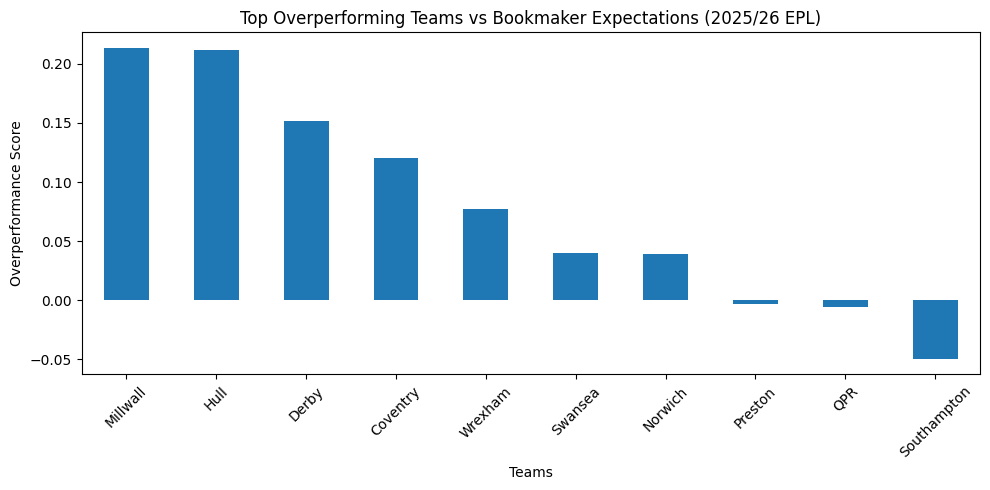

In [ ]:
import matplotlib.pyplot as plt

top_over = team_overperf.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_over.plot(kind="bar")

plt.title("Top Overperforming Teams vs Bookmaker Expectations (2025/26 EPL)")
plt.xlabel("Teams")
plt.ylabel("Overperformance Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Worst performing teams:

In [ ]:
team_overperf.tail(10)

,0
HomeTeam,
Oxford,-0.095248
Stoke,-0.097574
Ipswich,-0.139883
Sheffield United,-0.143925
Blackburn,-0.154569
Watford,-0.180631
Birmingham,-0.203899
Sheffield Weds,-0.265948
West Brom,-0.290008


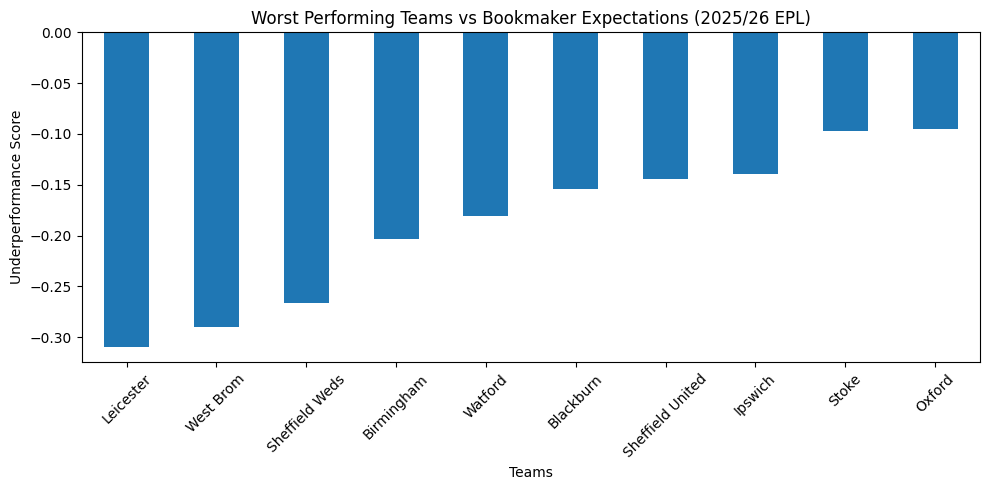

In [ ]:
bottom_over = team_overperf.sort_values(ascending=True).head(10)

plt.figure(figsize=(10,5))
bottom_over.plot(kind="bar")

plt.title("Worst Performing Teams vs Bookmaker Expectations (2025/26 EPL)")
plt.xlabel("Teams")
plt.ylabel("Underperformance Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

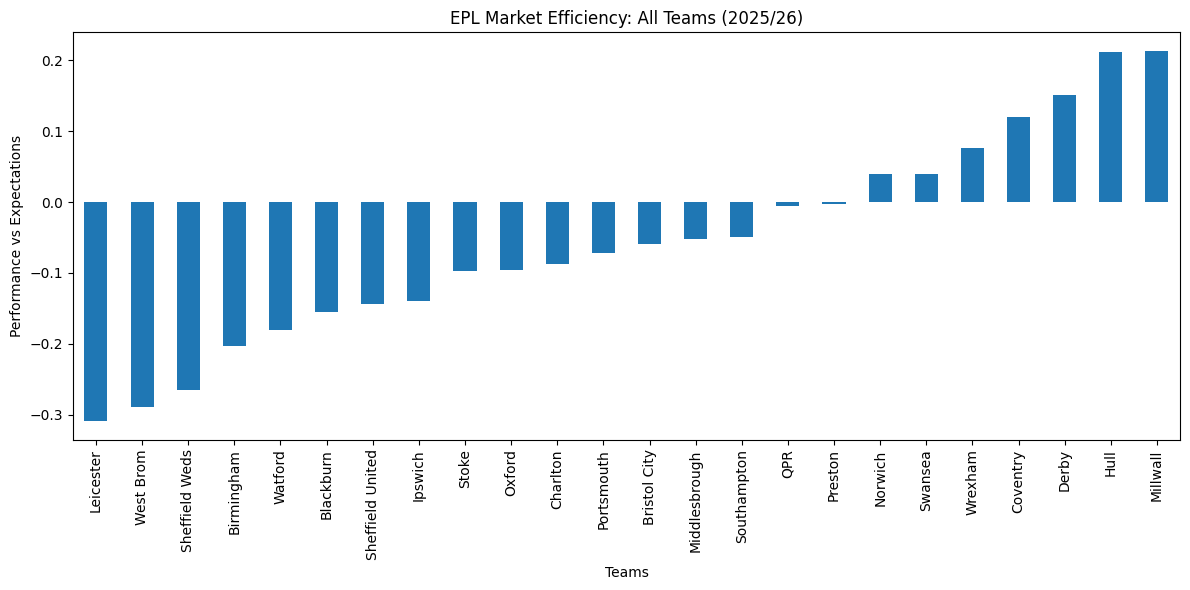

In [ ]:
plt.figure(figsize=(12,6))
team_overperf.sort_values().plot(kind="bar")

plt.title("EPL Market Efficiency: All Teams (2025/26)")
plt.xlabel("Teams")
plt.ylabel("Performance vs Expectations")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Which teams create the highest-quality scoring chances?

# CREATE HOME TEAM ATTACKING METRICS

In [ ]:
home_stats = df.groupby("HomeTeam").agg({
    "HS": "sum",      # Home Shots
    "HST": "sum",     # Home Shots on Target
    "FTHG": "sum"     # Home Goals
})


# CREATE AWAY TEAM ATTACKING METRICS

In [ ]:
away_stats = df.groupby("AwayTeam").agg({
    "AS": "sum",      # Away Shots
    "AST": "sum",     # Away Shots on Target
    "FTAG": "sum"     # Away Goals
})

# Rename columns to match home stats


In [ ]:
away_stats.columns = ["HS", "HST", "FTHG"]


# COMBINE HOME + AWAY DATA

In [ ]:
team_stats = home_stats.add(away_stats, fill_value=0)


# CALCULATE ATTACKING METRICS

In [ ]:
# Shot Accuracy
team_stats["Shot_Accuracy"] = (
    team_stats["HST"] / team_stats["HS"]
)

# Conversion Rate
team_stats["Conversion_Rate"] = (
    team_stats["FTHG"] / team_stats["HS"]
)

# Shots on Target per Match
matches_played = 46  # Championship season
team_stats["Shots_On_Target_Per_Game"] = (
    team_stats["HST"] / matches_played
)

# Goals per Match
team_stats["Goals_Per_Game"] = (
    team_stats["FTHG"] / matches_played
)

# -----------------------------------------
# SORT BY SHOT ACCURACY
# -----------------------------------------
team_stats = team_stats.sort_values(
    by="Shot_Accuracy",
    ascending=False
)

In [ ]:
team_stats.head(50)

,HS,HST,FTHG,Shot_Accuracy,Conversion_Rate,Shots_On_Target_Per_Game,Goals_Per_Game
HomeTeam,,,,,,,
Southampton,667,245,82,0.367316,0.122939,5.326087,1.782609
Hull,515,189,70,0.366990,0.135922,4.108696,1.521739
Norwich,580,205,63,0.353448,0.108621,4.456522,1.369565
Coventry,751,256,97,0.340879,0.129161,5.565217,2.108696
Ipswich,693,234,80,0.337662,0.115440,5.086957,1.739130
Stoke,518,174,51,0.335907,0.098456,3.782609,1.108696
Bristol City,560,188,59,0.335714,0.105357,4.086957,1.282609
Wrexham,520,173,69,0.332692,0.132692,3.760870,1.500000
Preston,502,165,55,0.328685,0.109562,3.586957,1.195652


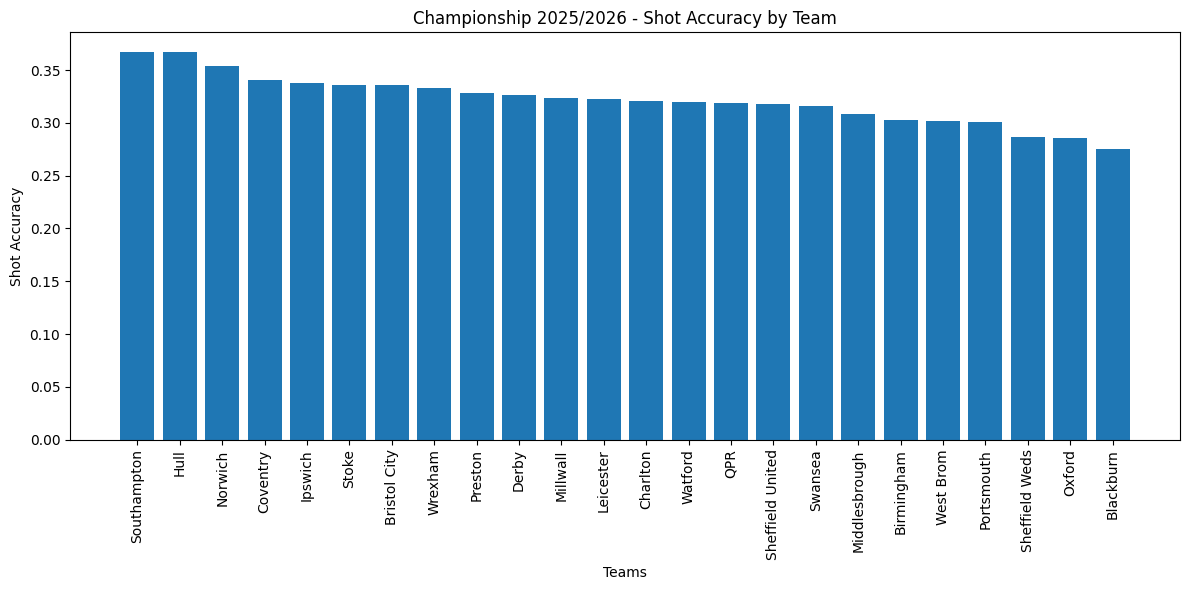

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    team_stats.index,
    team_stats["Shot_Accuracy"]
)

plt.xticks(rotation=90)

plt.ylabel("Shot Accuracy")
plt.xlabel("Teams")

plt.title(
    "Championship 2025/2026 - Shot Accuracy by Team"
)

plt.tight_layout()
plt.show()

# Which clubs are inefficient in converting chances?


League Average Conversion Rate: 0.103

Inefficient Attacking Teams:

                HS  HST  FTHG  Shot_Accuracy  Conversion_Rate  Goals_Per_Game
HomeTeam                                                                     
West Brom      616  186    48          0.302            0.078           1.043
Watford        639  204    53          0.319            0.083           1.152
Birmingham     627  190    57          0.303            0.091           1.239
Middlesbrough  743  229    72          0.308            0.097           1.565
Leicester      592  191    58          0.323            0.098           1.261


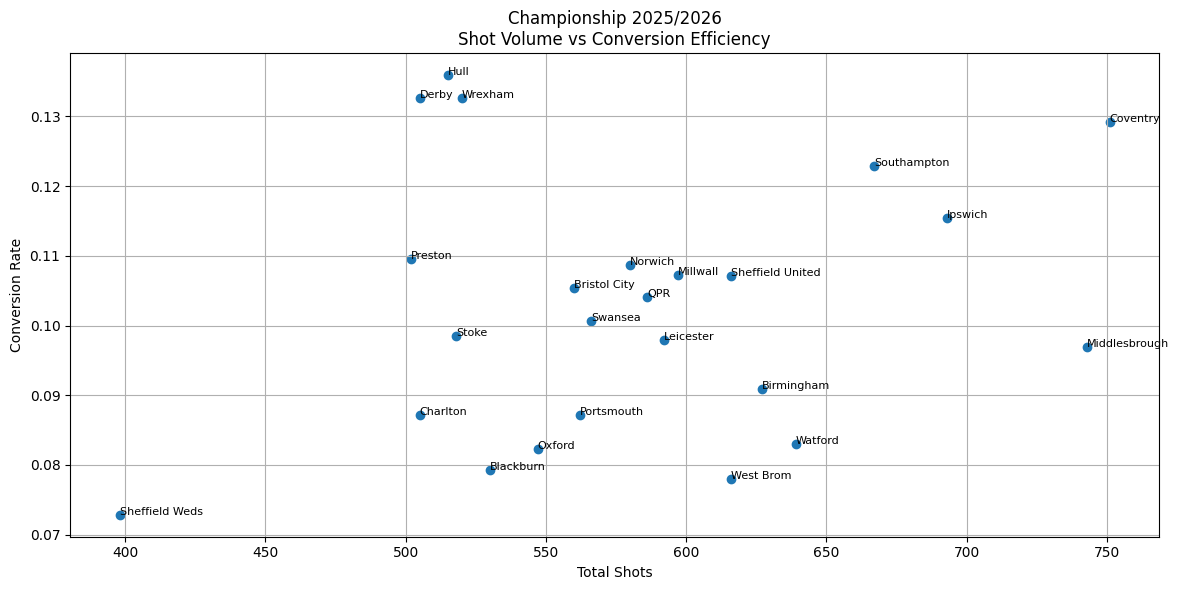

In [ ]:
# -----------------------------------------
# HOME TEAM ATTACKING DATA
# -----------------------------------------
home_stats = df.groupby("HomeTeam").agg({
    "HS": "sum",      # Home Shots
    "HST": "sum",     # Home Shots on Target
    "FTHG": "sum"     # Home Goals
})

# -----------------------------------------
# AWAY TEAM ATTACKING DATA
# -----------------------------------------
away_stats = df.groupby("AwayTeam").agg({
    "AS": "sum",      # Away Shots
    "AST": "sum",     # Away Shots on Target
    "FTAG": "sum"     # Away Goals
})

# Rename columns
away_stats.columns = ["HS", "HST", "FTHG"]

# -----------------------------------------
# COMBINE HOME + AWAY DATA
# -----------------------------------------
team_stats = home_stats.add(away_stats, fill_value=0)

# -----------------------------------------
# CALCULATE METRICS
# -----------------------------------------

# Shot Accuracy
team_stats["Shot_Accuracy"] = (
    team_stats["HST"] / team_stats["HS"]
)

# Conversion Rate
team_stats["Conversion_Rate"] = (
    team_stats["FTHG"] / team_stats["HS"]
)

# Goals per Game
matches_played = 46

team_stats["Goals_Per_Game"] = (
    team_stats["FTHG"] / matches_played
)

# -----------------------------------------
# IDENTIFY INEFFICIENT TEAMS
# -----------------------------------------
# High shot volume + low conversion

league_avg_conversion = (
    team_stats["Conversion_Rate"].mean()
)

league_avg_shots = (
    team_stats["HS"].mean()
)

inefficient_teams = team_stats[
    (team_stats["HS"] > league_avg_shots) &
    (team_stats["Conversion_Rate"] < league_avg_conversion)
]

# Sort by lowest conversion rate
inefficient_teams = inefficient_teams.sort_values(
    by="Conversion_Rate"
)

# -----------------------------------------
# DISPLAY RESULTS
# -----------------------------------------
print("\nLeague Average Conversion Rate:",
      round(league_avg_conversion, 3))

print("\nInefficient Attacking Teams:\n")

print(
    inefficient_teams[[
        "HS",
        "HST",
        "FTHG",
        "Shot_Accuracy",
        "Conversion_Rate",
        "Goals_Per_Game"
    ]].round(3)
)

# -----------------------------------------
# VISUALIZATION
# -----------------------------------------

plt.figure(figsize=(12, 6))

plt.scatter(
    team_stats["HS"],
    team_stats["Conversion_Rate"]
)

# Add team labels
for team in team_stats.index:
    plt.text(
        team_stats.loc[team, "HS"],
        team_stats.loc[team, "Conversion_Rate"],
        team,
        fontsize=8
    )

plt.xlabel("Total Shots")
plt.ylabel("Conversion Rate")

plt.title(
    "Championship 2025/2026\n"
    "Shot Volume vs Conversion Efficiency"
)

plt.grid(True)

plt.tight_layout()
plt.show()

# How accurate are bookmaker odds in predicting Championship matches?

                  Expected_Points  Actual_Points  Performance_Gap
HomeTeam                                                         
Millwall                    65.72             83            17.28
Hull                        57.28             73            15.72
Coventry                    81.68             95            13.32
Wrexham                     60.59             71            10.41
Derby                       58.83             69            10.17
Preston                     54.42             60             5.58
Southampton                 76.05             80             3.95
Swansea                     60.13             64             3.87
Middlesbrough               76.28             80             3.72
Norwich                     62.48             65             2.52
QPR                         57.47             58             0.53
Ipswich                     84.27             84            -0.27
Portsmouth                  56.18             55            -1.18
Bristol Ci

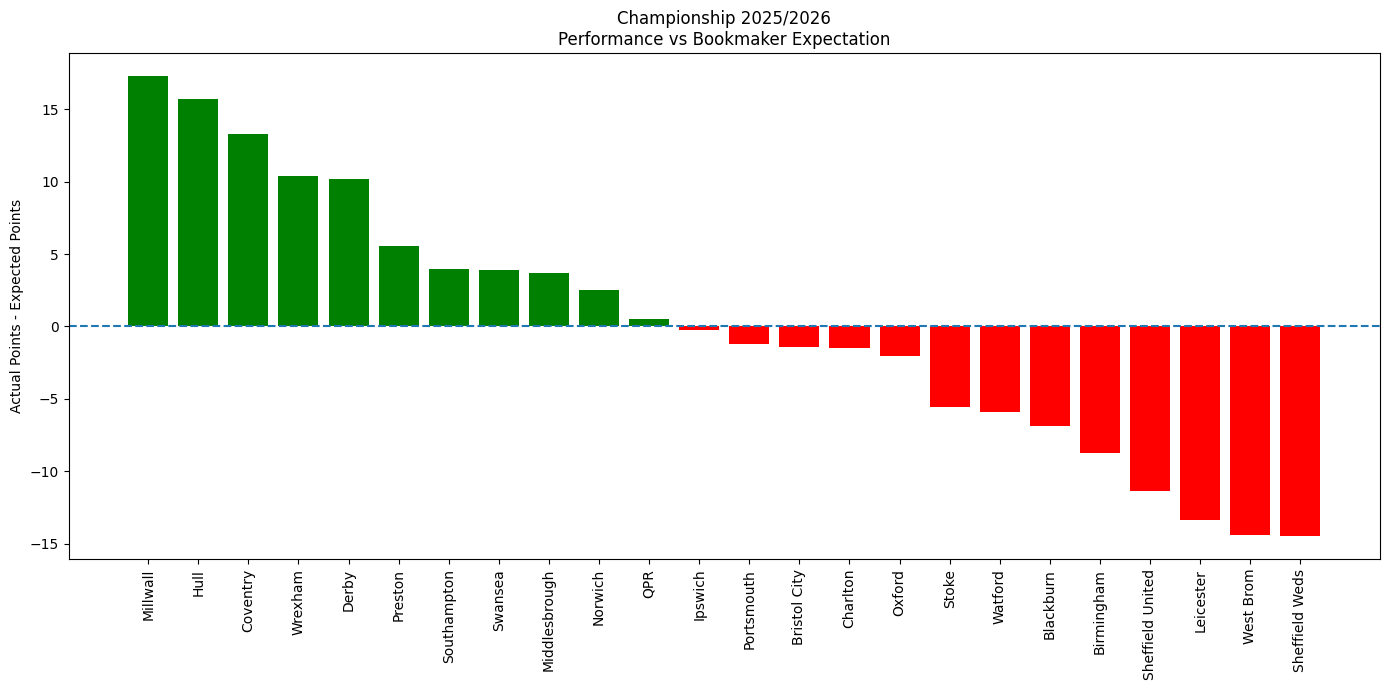

In [ ]:
# -----------------------------------------
# CONVERT ODDS TO IMPLIED PROBABILITIES
# -----------------------------------------

# Raw probabilities
df["P_Home"] = 1 / df["B365H"]
df["P_Draw"] = 1 / df["B365D"]
df["P_Away"] = 1 / df["B365A"]

# Overround (bookmaker margin)
df["Total_Prob"] = (
    df["P_Home"] +
    df["P_Draw"] +
    df["P_Away"]
)

# Normalize probabilities
df["P_Home_Norm"] = (
    df["P_Home"] / df["Total_Prob"]
)

df["P_Draw_Norm"] = (
    df["P_Draw"] / df["Total_Prob"]
)

df["P_Away_Norm"] = (
    df["P_Away"] / df["Total_Prob"]
)

# -----------------------------------------
# CALCULATE EXPECTED POINTS
# -----------------------------------------

# Home expected points
df["Home_xPTS"] = (
    3 * df["P_Home_Norm"] +
    1 * df["P_Draw_Norm"]
)

# Away expected points
df["Away_xPTS"] = (
    3 * df["P_Away_Norm"] +
    1 * df["P_Draw_Norm"]
)

# -----------------------------------------
# CALCULATE ACTUAL POINTS
# -----------------------------------------

# Home actual points
df["Home_Points"] = np.select(
    [
        df["FTR"] == "H",
        df["FTR"] == "D",
        df["FTR"] == "A"
    ],
    [3, 1, 0]
)

# Away actual points
df["Away_Points"] = np.select(
    [
        df["FTR"] == "A",
        df["FTR"] == "D",
        df["FTR"] == "H"
    ],
    [3, 1, 0]
)

# -----------------------------------------
# TEAM-LEVEL ANALYSIS
# -----------------------------------------

# Home team stats
home_table = df.groupby("HomeTeam").agg({
    "Home_xPTS": "sum",
    "Home_Points": "sum"
})

# Away team stats
away_table = df.groupby("AwayTeam").agg({
    "Away_xPTS": "sum",
    "Away_Points": "sum"
})

# Rename columns
away_table.columns = ["Home_xPTS", "Home_Points"]

# Combine home + away
team_table = home_table.add(
    away_table,
    fill_value=0
)

# Rename final columns
team_table.columns = [
    "Expected_Points",
    "Actual_Points"
]

# -----------------------------------------
# PERFORMANCE GAP
# -----------------------------------------

team_table["Performance_Gap"] = (
    team_table["Actual_Points"] -
    team_table["Expected_Points"]
)

# -----------------------------------------
# SORT TEAMS
# -----------------------------------------

team_table = team_table.sort_values(
    by="Performance_Gap",
    ascending=False
)

# -----------------------------------------
# DISPLAY RESULTS
# -----------------------------------------

print(team_table.round(2))

# -----------------------------------------
# VISUALIZATION
# -----------------------------------------

plt.figure(figsize=(14, 7))

colors = [
    "green" if x > 0 else "red"
    for x in team_table["Performance_Gap"]
]

plt.bar(
    team_table.index,
    team_table["Performance_Gap"],
    color=colors
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xticks(rotation=90)

plt.ylabel("Actual Points - Expected Points")

plt.title(
    "Championship 2025/2026\n"
    "Performance vs Bookmaker Expectation"
)

plt.tight_layout()
plt.show()

# What match statistics are most associated with winning matches?


Match Winning Factors Analysis

     Winning Teams  Non-Winning Teams  Difference
HS           14.50              13.75        0.75
HST           5.50               3.74        1.76
HC            5.37               6.06       -0.69
HF           10.27              10.31       -0.04
HY            1.63               1.66       -0.02


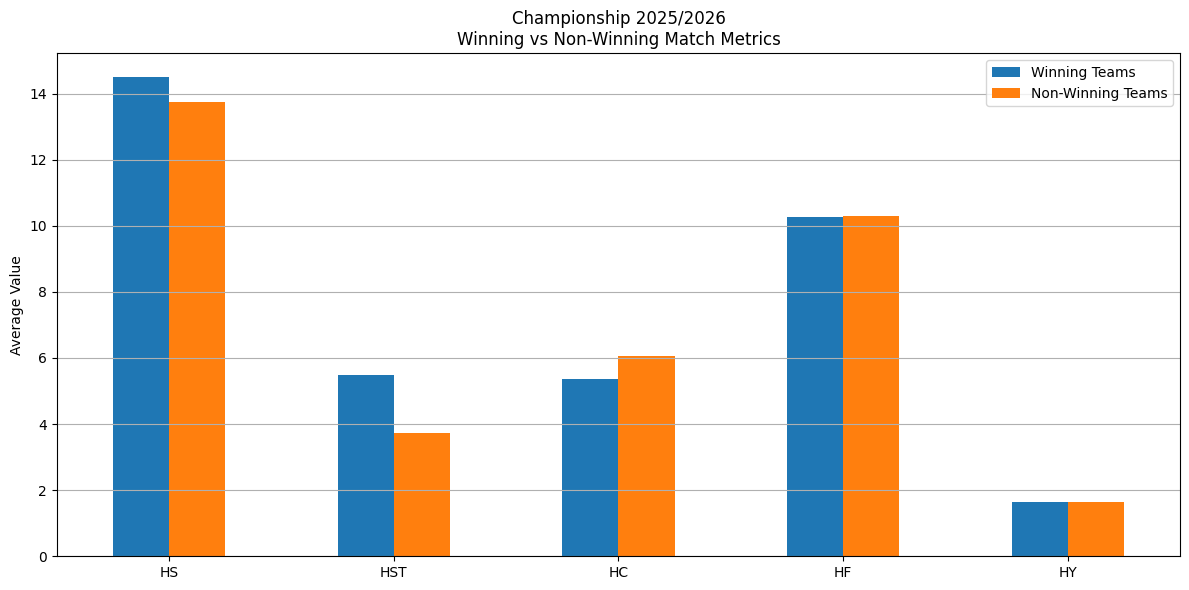


Correlation With Winning:

Home_Win    1.000
HST         0.375
HS          0.071
HF         -0.005
HY         -0.008
HC         -0.112
Name: Home_Win, dtype: float64


In [ ]:
# -----------------------------------------
# CREATE MATCH RESULT LABELS
# -----------------------------------------

# Home team win = 1
# Draw/Loss = 0

df["Home_Win"] = (
    df["FTR"] == "H"
).astype(int)

# -----------------------------------------
# SELECT IMPORTANT MATCH METRICS
# -----------------------------------------

metrics = [
    "HS",   # Home Shots
    "HST",  # Home Shots on Target
    "HC",   # Home Corners
    "HF",   # Home Fouls
    "HY"    # Home Yellow Cards
]

# -----------------------------------------
# CALCULATE AVERAGES
# -----------------------------------------

# Metrics when home team WON
win_stats = (
    df[df["Home_Win"] == 1][metrics]
    .mean()
)

# Metrics when home team DID NOT WIN
non_win_stats = (
    df[df["Home_Win"] == 0][metrics]
    .mean()
)

# -----------------------------------------
# CREATE COMPARISON TABLE
# -----------------------------------------

comparison = pd.DataFrame({
    "Winning Teams": win_stats,
    "Non-Winning Teams": non_win_stats
})

comparison["Difference"] = (
    comparison["Winning Teams"] -
    comparison["Non-Winning Teams"]
)

# -----------------------------------------
# DISPLAY RESULTS
# -----------------------------------------

print("\nMatch Winning Factors Analysis\n")
print(comparison.round(2))

# -----------------------------------------
# VISUALIZATION
# -----------------------------------------

comparison[[
    "Winning Teams",
    "Non-Winning Teams"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Championship 2025/2026\n"
    "Winning vs Non-Winning Match Metrics"
)

plt.ylabel("Average Value")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

# -----------------------------------------
# CORRELATION ANALYSIS
# -----------------------------------------

correlation_data = df[metrics + ["Home_Win"]]

correlations = correlation_data.corr()

# Correlation with winning
win_correlations = correlations["Home_Win"]\
    .sort_values(ascending=False)

print("\nCorrelation With Winning:\n")
print(win_correlations.round(3))